Lab 7 Valerie Jimenez and George

https://www.kaggle.com/datasets/mohamedasak/online-learning-student-dropout-dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
   # Split data into train/test sets  & Cross-validation for robust evaluation
from sklearn.model_selection import (train_test_split, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)


In [ ]:
df=pd.read_csv('student_dropout.csv')
df

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,STU04996,26,Baghdad,2024-07-10,0,2,7,0.6537,11.06,1,14,0.0000,0,0,active
4996,STU04997,34,Casablanca,2024-09-22,0,2,3,0.2559,5.16,15,3,0.3356,1,1,at-risk
4997,STU04998,18,Casablanca,2024-04-01,0,3,3,0.2242,5.05,5,6,0.2709,0,0,active
4998,STU04999,24,Beirut,2024-12-30,0,1,1,0.2659,4.04,1,4,0.2695,0,0,active


In [ ]:
df.drop(columns=['enroll_date', 'student_id', 'label', 'region', 'label_multiclass'], inplace=True)
df


,age,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label_name
0,26,0,3,5,0.3571,5.29,10,5,0.1064,active
1,23,0,6,0,0.0000,0.84,7,0,0.6627,dropped
2,17,0,3,1,0.0435,1.79,36,0,0.7299,dropped
3,23,0,6,13,0.4396,0.78,9,0,0.5315,at-risk
4,20,0,5,5,0.2078,0.92,11,0,0.7904,dropped
...,...,...,...,...,...,...,...,...,...,...
4995,26,0,2,7,0.6537,11.06,1,14,0.0000,active
4996,34,0,2,3,0.2559,5.16,15,3,0.3356,at-risk
4997,18,0,3,3,0.2242,5.05,5,6,0.2709,active
4998,24,0,1,1,0.2659,4.04,1,4,0.2695,active


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
label=le.fit_transform(df['label_name'])

df.drop("label_name", axis=1, inplace=True)
#appending the array to df
df["label_name"]=label
df
#active=0 droppped=2 at_risk=1

,age,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label_name
0,26,0,3,5,0.3571,5.29,10,5,0.1064,0
1,23,0,6,0,0.0000,0.84,7,0,0.6627,2
2,17,0,3,1,0.0435,1.79,36,0,0.7299,2
3,23,0,6,13,0.4396,0.78,9,0,0.5315,1
4,20,0,5,5,0.2078,0.92,11,0,0.7904,2
...,...,...,...,...,...,...,...,...,...,...
4995,26,0,2,7,0.6537,11.06,1,14,0.0000,0
4996,34,0,2,3,0.2559,5.16,15,3,0.3356,1
4997,18,0,3,3,0.2242,5.05,5,6,0.2709,0
4998,24,0,1,1,0.2659,4.04,1,4,0.2695,0


In [ ]:
df.describe()

,age,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label_name
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000
mean,23.736600,0.094000,3.999400,5.188400,0.260985,3.453820,9.3564,4.212200,0.431556,0.985800
std,4.583211,0.291858,1.997348,6.109466,0.249010,3.248316,9.4361,4.270131,0.263529,0.816904
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.100000,1.0000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,2.000000,1.000000,0.053900,0.980000,2.0000,1.000000,0.204575,0.000000
50%,24.000000,0.000000,4.000000,3.000000,0.206700,2.440000,6.0000,3.000000,0.441550,1.000000
75%,27.000000,0.000000,6.000000,7.000000,0.389025,4.942500,13.0000,6.000000,0.658325,2.000000
max,40.000000,1.000000,7.000000,35.000000,1.000000,14.000000,70.0000,24.000000,1.000000,2.000000


In [ ]:
df['courses_enrolled'].value_counts()

,count
courses_enrolled,
6,752
5,726
1,724
2,706
3,704
4,703
7,685


In [ ]:
df.columns

Index(['age', 'exam_season', 'courses_enrolled', 'completed_assignments',
       'completion_rate', 'login_frequency', 'last_activity_days_ago',
       'forum_posts_count', 'dropout_score', 'label_name'],
      dtype='object')

In [ ]:
np.random.seed(42)

n_active=100
active= pd.DataFrame({'exam_season': np.random.choice([0,1], n_active),
 'courses_enrolled': np.random.normal(3.99, 1.99, n_active), 'completed_assignments': np.random.normal(5.18, 6.19, n_active),
  'completion_rate': np.random.normal(.26, .24, n_active), 'login_frequency': np.random.normal(3.45, 3.2, n_active),
   'last_activity_days_ago': np.random.normal(9.35, 9.43, n_active), 'forum_posts_count': np.random.normal(4.21, 4.27, n_active),
   'dropout_score': np.random.normal(.43, .26, n_active), 'label_name': 'active'})

In [ ]:
n_dropped=100
dropped= pd.DataFrame({'exam_season': np.random.choice([0,1], n_dropped),
 'courses_enrolled': np.random.normal(3.99, 1.99, n_dropped), 'completed_assignments': np.random.normal(5.18, 6.19, n_dropped),
  'completion_rate': np.random.normal(.26, .24, n_dropped), 'login_frequency': np.random.normal(3.45, 3.2, n_dropped),
   'last_activity_days_ago': np.random.normal(9.35, 9.43, n_dropped), 'forum_posts_count': np.random.normal(4.21, 4.27, n_dropped),
   'dropout_score': np.random.normal(.43, .26, n_dropped), 'label_name': 'dropped'})

In [ ]:
n_at_risk=100
at_risk= pd.DataFrame({'exam_season': np.random.choice([0,1], n_at_risk),
 'courses_enrolled': np.random.normal(3.99, 1.99, n_at_risk), 'completed_assignments': np.random.normal(5.18, 6.19, n_at_risk),
  'completion_rate': np.random.normal(.26, .24, n_at_risk), 'login_frequency': np.random.normal(3.45, 3.2, n_at_risk),
   'last_activity_days_ago': np.random.normal(9.35, 9.43, n_at_risk), 'forum_posts_count': np.random.normal(4.21, 4.27, n_at_risk),
   'dropout_score': np.random.normal(.43, .26, n_at_risk), 'label_name': 'at_risk'})

In [ ]:

# Combine all three groups into one DataFrame
df = pd.concat([dropped, at_risk, active], ignore_index=True)
# Quick look at the data
print("STEP 2: Dataset Overview")
print("-" * 40)
print(f"Total samples:       {df.shape[0]}")        # 300
print(f"Number of features:  {df.shape[1] - 1}")    # 6 (excluding Age_Group)
print(f"Number of classes:   {df['label_name'].nunique()}")  # 3
print()

STEP 2: Dataset Overview
----------------------------------------
Total samples:       300
Number of features:  8
Number of classes:   3



In [ ]:
# Show how many of each age group we have
print("Class distribution:")
print(df['label_name'].value_counts().to_string())
#   Each class should have ~100 samples (balanced dataset)
print()

# Show a few sample rows
print("First 5 rows:")
print(df.head().to_string(index=False))
print()

Class distribution:
label_name
dropped    100
at_risk    100
active     100

First 5 rows:
 exam_season  courses_enrolled  completed_assignments  completion_rate  login_frequency  last_activity_days_ago  forum_posts_count  dropout_score label_name
           0          4.746594               2.150370         0.027926         2.420768               18.009726           7.233624       0.990900    dropped
           1          5.205066              11.643356         0.248549        10.095594               -5.459821           8.295119       0.272514    dropped
           0          5.103983               9.400908         0.259135         4.672193                0.017807           0.853825       0.622945    dropped
           0          6.140754              16.611118        -0.018008         4.826133               18.221472          -1.474365       0.507816    dropped
           1          5.649505               8.794515         0.620816         6.746907                0.085144          -3.

In [ ]:
# Average values for each group
print("Average measurements per group:")
print(df.groupby('label_name').mean().round(3))
print()

Average measurements per group:
            exam_season  courses_enrolled  completed_assignments  \
label_name                                                         
active             0.56             3.930                  5.873   
at_risk            0.54             3.789                  6.472   
dropped            0.45             4.276                  6.130   

            completion_rate  login_frequency  last_activity_days_ago  \
label_name                                                             
active                0.273            3.653                   7.537   
at_risk               0.243            3.447                   9.612   
dropped               0.285            4.014                   9.522   

            forum_posts_count  dropout_score  
label_name                                    
active                  4.414          0.421  
at_risk                 4.008          0.437  
dropped                 3.855          0.487  



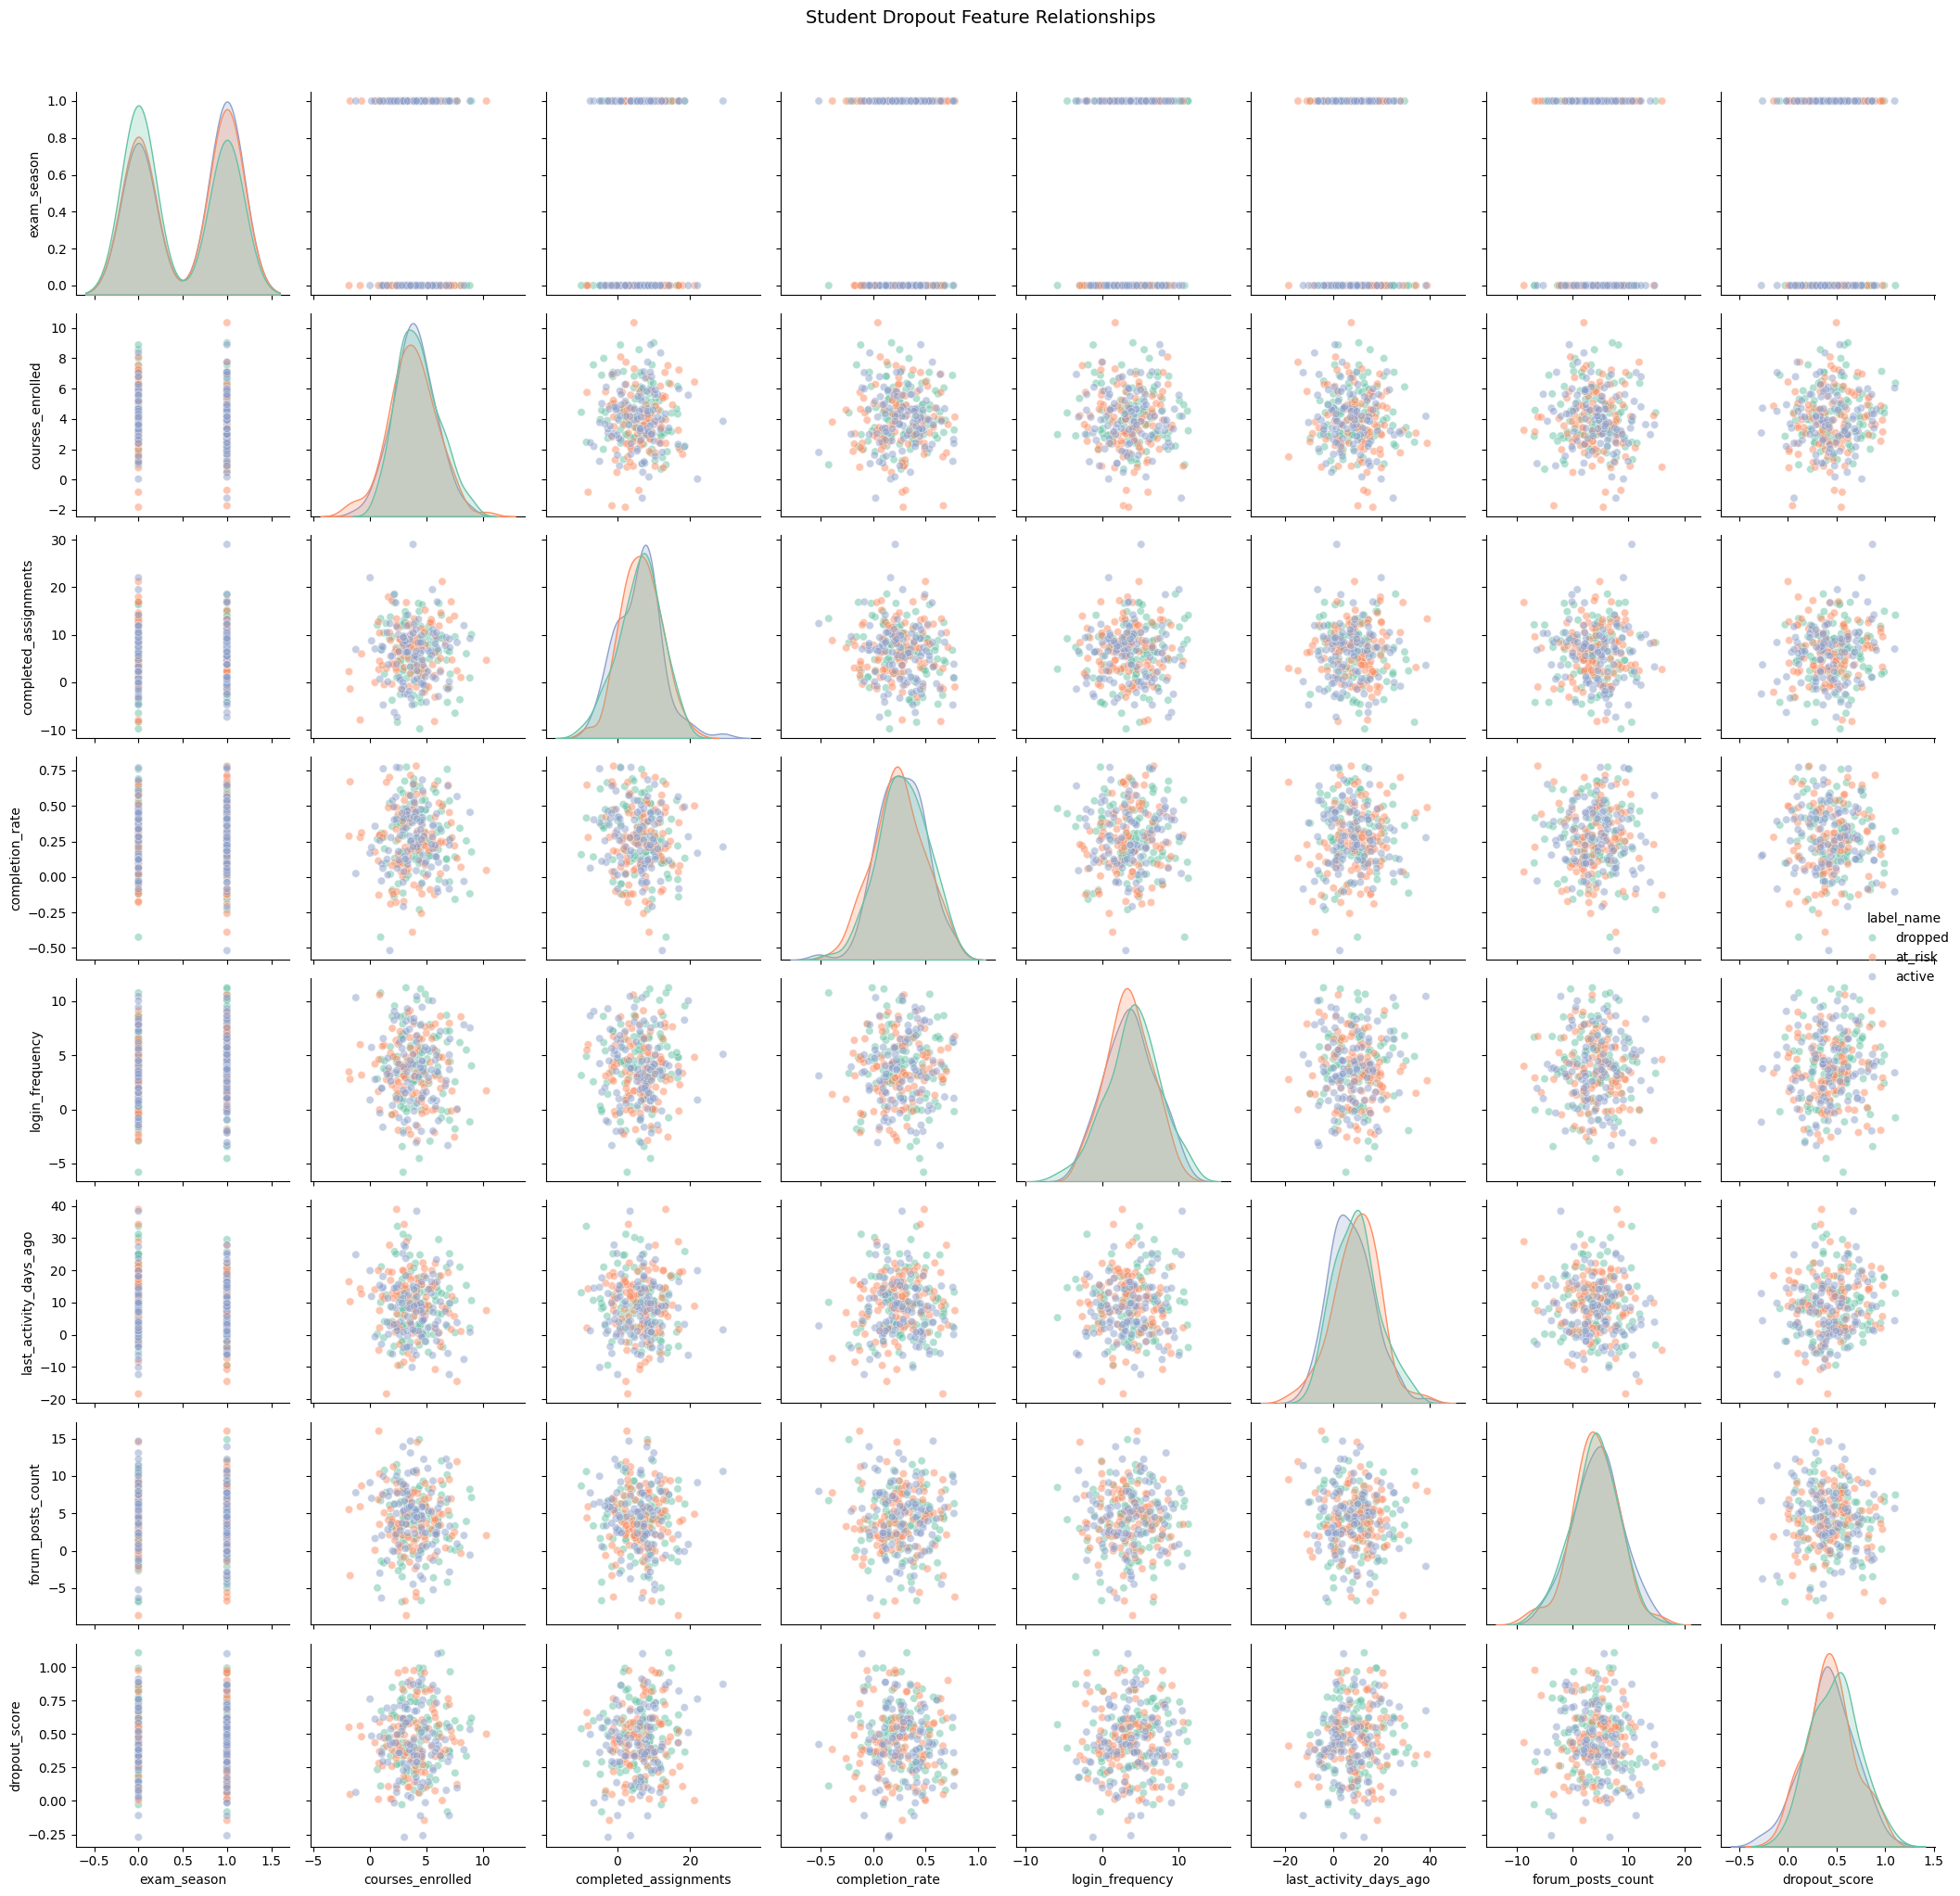

   -> Pair plot saved as 'student_dropout_pairplot.png'
   -> Look for features where the 3 colors separate well.
      Those features will be most useful for KNN!



In [ ]:
plot_features = ['exam_season', 'courses_enrolled', 'completed_assignments',
       'completion_rate', 'login_frequency', 'last_activity_days_ago',
       'forum_posts_count', 'dropout_score', 'label_name']

sns.pairplot(
    df[plot_features],         # Only these columns
    hue='label_name',           # Color by age group
    palette='Set2',            # A nice color palette
    diag_kind='kde',           # Diagonal: show density curves instead of histograms
    plot_kws={                 # Settings for the scatter plots
        'alpha': 0.5,          # Semi-transparent dots
        'edgecolor': 'w'       # White edges around dots
    })
plt.suptitle('Student Dropout Feature Relationships', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('student_dropout_pairplot.png', dpi=150)
plt.show()

print("   -> Pair plot saved as 'student_dropout_pairplot.png'")
print("   -> Look for features where the 3 colors separate well.")
print("      Those features will be most useful for KNN!")
print()

/tmp/ipykernel_504/2649855071.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


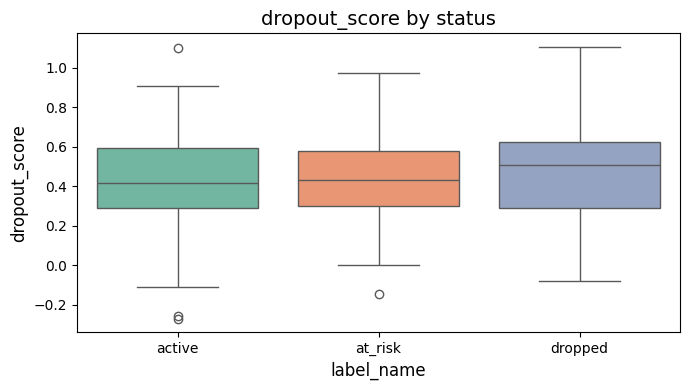

   -> Box plot saved as 'student_dropout_boxplot.png'



In [ ]:
# Box plots show the median, quartiles, and outliers
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x='label_name',             # Categories on x-axis
    y='dropout_score',          # Values on y-axis
    palette='Set2',            # Same colors as pair plot
    order=['active', 'at_risk', 'dropped']  # Force this order
)
plt.xlabel('label_name', fontsize=12)
plt.ylabel('dropout_score', fontsize=12)
plt.title('dropout_score by status', fontsize=14)
plt.tight_layout()
plt.savefig('student_dropout_boxplot.png', dpi=150)
plt.show()

print("   -> Box plot saved as 'student_dropout_boxplot.png'")
print()

In [ ]:
# Separate features from labels
X = df.drop('label_name', axis=1)    # All columns except the label
y = df['label_name']                 # Just the label column

# Split: 80% training, 20% testing
# stratify=y ensures each age group is proportionally represented
# in both the training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")  # 240
print(f"Testing samples:  {X_test.shape[0]}")   # 60
print()

# Verify the class balance in both sets
print("Class balance check:")
print(f"  Training: {dict(y_train.value_counts())}")
print(f"  Testing:  {dict(y_test.value_counts())}")
print("  (Should be roughly proportional)")
print()

Training samples: 240
Testing samples:  60

Class balance check:
  Training: {'active': np.int64(80), 'at_risk': np.int64(80), 'dropped': np.int64(80)}
  Testing:  {'active': np.int64(20), 'dropped': np.int64(20), 'at_risk': np.int64(20)}
  (Should be roughly proportional)



In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Learn + scale
X_test_scaled  = scaler.transform(X_test)         # Scale only (no learning)

print("Features scaled with StandardScaler.")
print()


Features scaled with StandardScaler.



In [ ]:
# Create and train the model
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
# Make predictions
y_pred = knn.predict(X_test_scaled)

# --- Accuracy ---
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")
print()

Overall Accuracy: 30.00%



In [ ]:
# --- Classification Report ---
# For multiclass problems, this shows precision/recall/f1 for EACH class
# plus macro avg (simple average) and weighted avg (accounts for class size)
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

      active       0.33      0.50      0.40        20
     at_risk       0.21      0.15      0.18        20
     dropped       0.31      0.25      0.28        20

    accuracy                           0.30        60
   macro avg       0.29      0.30      0.28        60
weighted avg       0.29      0.30      0.28        60



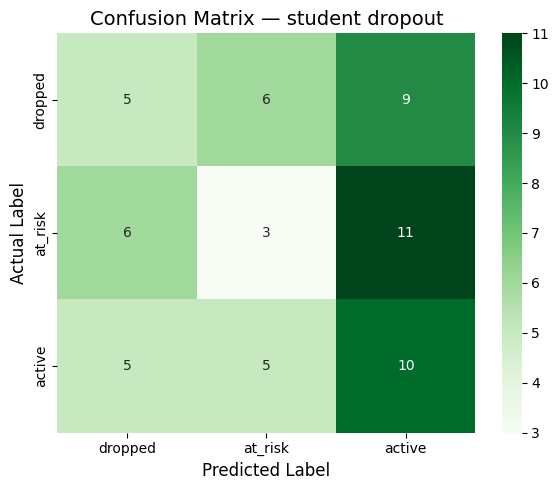

   -> Confusion matrix saved as 'student_dropout_confusion.png'



In [ ]:
cm = confusion_matrix(
    y_test, y_pred,
    labels=['dropped', 'at_risk', 'active']  # Force this order in the matrix
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,                                    # Show numbers
    fmt='d',                                       # Integer format
    cmap='Greens',                                 # Green color scheme
    xticklabels=['dropped', 'at_risk', 'active'],        # Predicted labels
    yticklabels=['dropped', 'at_risk', 'active']         # Actual labels
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Confusion Matrix — student dropout', fontsize=14)
plt.tight_layout()
plt.savefig('student_dropout_confusion.png', dpi=150)
plt.show()

print("   -> Confusion matrix saved as 'student_dropout_confusion.png'")
print()

In [ ]:
# Test K from 1 to 30
k_range = range(1, 31)

# For each K, we'll store:
#   - The mean CV accuracy (average across 5 folds)
#   - The std of CV accuracy (how much it varies between folds)
cv_means = []    # Average accuracy
cv_stds = []     # Standard deviation (spread)

for k in k_range:
    # Create a model with this K
    model = KNeighborsClassifier(n_neighbors=k)

    # Run 5-fold cross-validation on the TRAINING data only
    # cross_val_score returns an array of 5 accuracy scores
    scores = cross_val_score(
        model,                   # The model to evaluate
        X_train_scaled,          # The training features (scaled)
        y_train,                 # The training labels
        cv=5,                    # 5 folds
        scoring='accuracy'       # Metric to use
    )

    # Store the mean and standard deviation
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

    # Print progress every 5 steps
    if k % 5 == 0 or k == 1:
        print(f"   K={k:2d} → CV Accuracy = {scores.mean():.2%} (±{scores.std():.2%})")

print()


   K= 1 → CV Accuracy = 30.00% (±6.12%)
   K= 5 → CV Accuracy = 30.42% (±5.53%)
   K=10 → CV Accuracy = 34.58% (±7.97%)
   K=15 → CV Accuracy = 32.50% (±7.52%)
   K=20 → CV Accuracy = 36.67% (±3.63%)
   K=25 → CV Accuracy = 34.58% (±5.98%)
   K=30 → CV Accuracy = 33.75% (±4.82%)



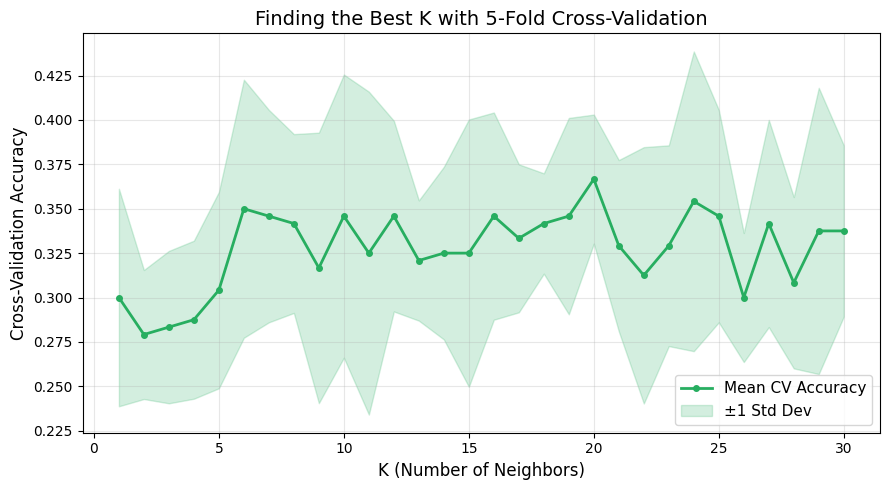

   -> Best K = 20
   -> Best CV Accuracy = 36.67%
   -> Chart saved as 'student_dropout_best_k.png'



In [ ]:
plt.figure(figsize=(9, 5))

# Convert to numpy arrays for easy math
cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)
k_list = list(k_range)

# Main line (mean accuracy)
plt.plot(k_list, cv_means, marker='o', color='#27ae60',
         linewidth=2, markersize=4, label='Mean CV Accuracy')

# Shaded region (±1 standard deviation)
# This shows the UNCERTAINTY in our accuracy estimate
plt.fill_between(
    k_list,
    cv_means - cv_stds,     # Lower bound
    cv_means + cv_stds,     # Upper bound
    alpha=0.2,              # Transparency
    color='#27ae60',        # Same green
    label='±1 Std Dev'
)

plt.xlabel('K (Number of Neighbors)', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Finding the Best K with 5-Fold Cross-Validation', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('student_dropout_best_k.png', dpi=150)
plt.show()

# Find the best K
best_k = k_list[np.argmax(cv_means)]
best_cv_accuracy = cv_means.max()

print(f"   -> Best K = {best_k}")
print(f"   -> Best CV Accuracy = {best_cv_accuracy:.2%}")
print(f"   -> Chart saved as 'student_dropout_best_k.png'")
print()


In [ ]:
# Retrain with the best K
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

# Final predictions on the test set
y_pred_final = final_model.predict(X_test_scaled)

# Final accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final Test Accuracy (K={best_k}): {final_accuracy:.2%}")
print()

# Final classification report
print("Final Classification Report:")
print(classification_report(y_test, y_pred_final))


Final Test Accuracy (K=20): 36.67%

Final Classification Report:
              precision    recall  f1-score   support

      active       0.35      0.40      0.37        20
     at_risk       0.35      0.35      0.35        20
     dropped       0.41      0.35      0.38        20

    accuracy                           0.37        60
   macro avg       0.37      0.37      0.37        60
weighted avg       0.37      0.37      0.37        60



In [ ]:
#new dataset measurements
new_student_dropout = pd.DataFrame({
'exam_season': np.random.choice([0,1]),
'courses_enrolled':       [0.30, 0.58, 0.68],
'completed_assignments':     [0.22, 0.45, 0.55],
'completion_rate': [.35, .40, .55],
'login_frequency':       [0.07, 0.15, 0.19],
'last_activity_days_ago': [0.15, 0.85, 1.40],
'forum_posts_count': [0.05, 0.25, 0.42],
'dropout_score': [0.05, 0.25, 0.42]})

print("New student dropout measurements:")
print(new_student_dropout.to_string(index=False))
print()

New student dropout measurements:
 exam_season  courses_enrolled  completed_assignments  completion_rate  login_frequency  last_activity_days_ago  forum_posts_count  dropout_score
           1              0.30                   0.22             0.35             0.07                    0.15               0.05           0.05
           1              0.58                   0.45             0.40             0.15                    0.85               0.25           0.25
           1              0.68                   0.55             0.55             0.19                    1.40               0.42           0.42



In [ ]:
new_scaled = scaler.transform(new_student_dropout)

# Get predictions and probabilities
predictions = final_model.predict(new_scaled)
probabilities = final_model.predict_proba(new_scaled)

# Display results for each abalone
class_labels = final_model.classes_  # ['active', 'at risk', 'dropped'] (alphabetical)

for i in range(len(new_student_dropout)):
    print(f"label_name #{i+1}:")
    print(f"   Predicted dropout group: {predictions[i]}")
    print(f"   Confidence breakdown:")

    for cls, prob in zip(class_labels, probabilities[i]):
        # Visual bar to make probabilities easy to read
        bar_length = int(prob * 25)
        bar = '█' * bar_length + '░' * (25 - bar_length)
        print(f"      {cls:8s} {bar} {prob:6.1%}")
    print()

print()



label_name #1:
   Predicted dropout group: at_risk
   Confidence breakdown:
      active   ████████░░░░░░░░░░░░░░░░░  35.0%
      at_risk  ██████████░░░░░░░░░░░░░░░  40.0%
      dropped  ██████░░░░░░░░░░░░░░░░░░░  25.0%

label_name #2:
   Predicted dropout group: at_risk
   Confidence breakdown:
      active   ████████░░░░░░░░░░░░░░░░░  35.0%
      at_risk  ████████████░░░░░░░░░░░░░  50.0%
      dropped  ███░░░░░░░░░░░░░░░░░░░░░░  15.0%

label_name #3:
   Predicted dropout group: active
   Confidence breakdown:
      active   ██████████░░░░░░░░░░░░░░░  40.0%
      at_risk  ████████░░░░░░░░░░░░░░░░░  35.0%
      dropped  ██████░░░░░░░░░░░░░░░░░░░  25.0%




We used KNN to classify whether a student is likely to drop out or remain active based on their similarity to other students in the dataset. It works by comparing features such as completion rate, login frequency, courses enrolled, and recent activity, then calculating the distance between students to identify the closest “neighbors.” The model assigns a prediction based on the majority outcome among these neighbors. It requires proper preprocessing, including removing irrelevant fields, encoding categorical variables, and scaling features, since it relies heavily on distance calculations.Our Final Test Accuracy (K=20) was 36.67%.